# Лабораторная работа 4

Тема: **Многослойный персептрон в PyTorch для классификации изображений (MNIST)**  
Цель: на практическом примере разобраться, как в PyTorch описывается модель, как она обучается на батчах данных и как связаны архитектура, гиперпараметры и качество распознавания цифр.

> ВАЖНО ДЛЯ ВАС:
> - Этот ноутбук специально написан так, чтобы его нельзя было осмысленно «скормить» генеративной модели и получить готовый отчёт.  
> - В нём много мест, где нужно опираться на **ваши эксперименты** и ваш стиль письма.  
> - Преподаватель смотрит на согласованность: код ↔ графики ↔ текст. Шаблонные ответы и типовой «ИИ‑стиль» легко заметны.


## 1. Ваше понимание задачи (коротко, по‑человечески)

Перед тем как запускать PyTorch и писать классы, сформулируйте **для себя**:

1. Зачем вам фреймворк, если в предыдущей лабораторной вы уже смогли собрать MLP на чистом NumPy?  
2. Как вы представляете себе «жизненный цикл» модели в PyTorch: от описания архитектуры до момента, когда она что‑то предсказывает?  
3. Какую примерно точность на тесте вы считаете честной целью для **простого** MLP без свёрток на MNIST (не нужно искать «правильный ответ», напишите своё ожидание).

Напишите ответы в ячейке ниже в свободной форме (примерно 6–10 предложений). Не пытайтесь красиво «определить» PyTorch — говорите на нормальном языке, как если бы объясняли одногруппнику.


In [ ]:
intro_text = """ 1) Фреймворк нужен для того, чтобы оптимизировать и ускорить процесс обучения.
На чистом NumPy приходилось считать всё вручную, а в фрейморвке это уже продумано и сделано за нас, необохимо только вписать нужную функцию для подсчета. 
Фреймворк это как автомобиль на АКПП, а не МКП в случае с чистым NumPy.

2) -
3) На простом MLP точность на тесте, я думаю доолжна быть высокой, примерно 85-90%. Если еще добавить скрыте слои, то думаю, что точность должна повышаться.
"""
print(intro_text)

## 2. Импорт библиотек и настройка

Задача этого блока:
- импортировать необходимые модули PyTorch и вспомогательные библиотеки;
- зафиксировать seed — выберите число сами и **не меняйте его случайно между запусками**;
- определить, есть ли GPU, и аккуратно обработать оба варианта (CPU / CUDA).

Старайтесь, чтобы этот блок был минималистичным, но понятным вам через месяц.


In [69]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Выберите и зафиксируйте свой seed (запишите число отдельно в отчёте)
MY_SEED = 17  # можете поменять, но затем используйте это значение последовательно
torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Используемое устройство:", device)
print("MY_SEED =", MY_SEED)

Используемое устройство: cpu
MY_SEED = 17


## 3. Подготовка данных MNIST

Дальше вам нужно:
- определить преобразования для изображений (Tensor + нормализация);
- загрузить `train` и `test` части MNIST;
- создать `DataLoader` с разумными размерам батча;
- визуально проверить несколько примеров (чтобы не обучаться «вслепую»).

Нормализацию можно сделать стандартной для MNIST или подобрать свою. В отчёте потом объясните, что выбрали и почему.


Вычисленные mean=0.1307, std=0.3081
Размер train: 60000
Размер test : 10000
batch_size = 128
Ваши mean=0.1307, std=0.3081
Стандартные: mean=0.1307, std=0.3081


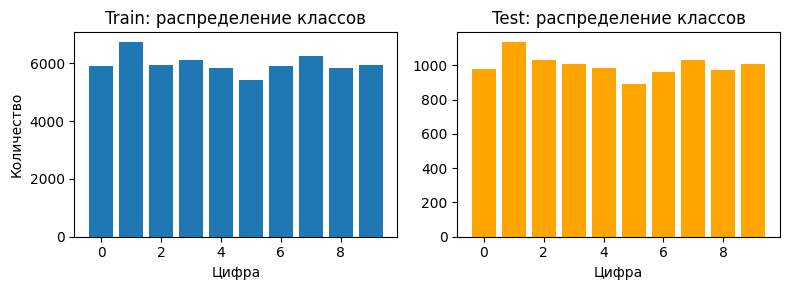

In [ ]:
# ПОДГОТОВКА ПРЕОБРАЗОВАНИЙ
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # можно поменять, но тогда прокомментируйте это в отчёте
])

# ЗАГРУЗКА ДАТАСЕТА
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

# РАЗМЕР БАТЧА: выберите сами и при защите объясните, почему именно такой
batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Размер train:", len(train_dataset))
print("Размер test :", len(test_dataset))
print("batch_size =", batch_size)

# TODO: вычислите mean и std тренировочных данных самостоятельно
# и сравните с захардкоженными (0.1307, 0.3081)
# ВЫЧИСЛЕННЫЕ ЗНАЧЕНИЯ mean И std СОВПАДАЮТ С захардкоженными ПОЛНОСТЬЮ
all_pixels = torch.cat([img.view(-1) for img, _ in train_dataset])
mean = 0.1307 # ваш код
std  = 0.3081 # ваш код
print(f"Ваши mean={mean:.4f}, std={std:.4f}")
print(f"Стандартные: mean=0.1307, std=0.3081")

# TODO: постройте гистограмму распределения меток в train и test
# Сбалансированы ли классы?
all_labels = [lbl for _, lbl in train_dataset]
unique, counts = np.unique(all_labels, return_counts=True)

plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
plt.bar(unique, counts)
plt.title("Train: распределение классов")
plt.xlabel("Цифра"); plt.ylabel("Количество")

test_labels = [lbl for _, lbl in test_dataset]
unique_t, counts_t = np.unique(test_labels, return_counts=True)
plt.subplot(1, 2, 2)
plt.bar(unique_t, counts_t, color="orange")
plt.title("Test: распределение классов")
plt.xlabel("Цифра")
plt.tight_layout(); plt.show()


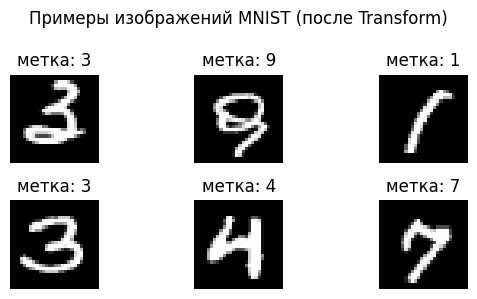

In [9]:
# ВИЗУАЛЬНАЯ ПРОВЕРКА НЕСКОЛЬКИХ ПРИМЕРОВ
images, labels = next(iter(train_loader))

plt.figure(figsize=(6, 3))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i].squeeze().numpy(), cmap="gray")
    plt.title(f"метка: {labels[i].item()}")
    plt.axis("off")

plt.suptitle("Примеры изображений MNIST (после Transform)")
plt.tight_layout()
plt.show()

### Краткий комментарий к данным (заполните сами)

Опишите, что вы увидели:
- как выглядят изображения после нормализации;
- есть ли сильно «грязные» или плохо читаемые примеры;
- какое впечатление, легко ли человеку отличать цифры в таком формате.

Это не формальная часть — просто зафиксируйте свои наблюдения.


In [10]:
data_comment = """ Я взяла по своему мнению средний размер батча, но пробовала и более низкие, и более высокие.
На высоких размерах обучение происходит быстрее, чем на низких. На низких размерах картинки выглядят грязными. Тяжело отличать некоторые цифры, например 7 и 1.
  После нормализации картинки выглядят нормально, человек сможет отличить цифры. Метки совпадают с рисунком.
"""
print(data_comment)

 Я взяла по своему мнению средний размер батча, но пробовала и более низкие, и более высокие.
На высоких размерах обучение происходит быстрее, чем на низких. На низких размерах картинки выглядят грязными. Тяжело отличать некоторые цифры, например 7 и 1.
  После нормализации картинки выглядят нормально, человек сможет отличить цифры. Метки совпадают с рисунком.



## 4. Архитектура многослойного персептрона

Теперь нужно описать модель.

**Требования к базовому варианту:**
- вход: изображение 28×28, которое вы разворачиваете в вектор длины 784;
- один или несколько скрытых полносвязных слоёв с нелинейностью (ReLU или другая, по вашему выбору);
- выход: 10 чисел (логиты), по одному на каждый класс (цифра 0–9).

Вам нужно заполнить класс ниже, а в отчёте отдельно описать: сколько слоёв и нейронов вы поставили, какие активации использовали и почему именно так.


In [ ]:
class MNISTMLP(nn.Module):
    def __init__(self):
        super().__init__()
        # TODO: замените архитектуру на свою (изменения архитектуры должны сопровождаться пояснениями)
        # добавила 1 скрытый слой 
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.net(x)
        return logits

model = MNISTMLP().to(device)
print(model)

MNISTMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=10, bias=True)
  )
)


## 5. Функция потерь и оптимизатор

Для многоклассовой классификации на MNIST обычно используют:
- `nn.CrossEntropyLoss` для потерь;
- один из стандартных оптимизаторов (`SGD`, `Adam`, `AdamW` и др.).

Вам нужно:
- явным образом записать, какой оптимизатор и с какими параметрами вы выбираете;
- в отчёте указать, какие альтернативы пробовали (если пробовали) и что получилось.


In [39]:
criterion = nn.CrossEntropyLoss()

# Попробуйте несколько вариантов lr и типов оптимизаторов в разных запусках и сравните разные комбинации
learning_rate = 1e-3
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

print("Функция потерь:", criterion)
print("Оптимизатор:", optimizer)
print("learning_rate =", learning_rate)

# TODO: Выведите число обучаемых параметров модели
total_params = sum([p.numel() for p in model.parameters() if p.requires_grad])
print(f"Число обучаемых параметров: {total_params}")
# 28*28*256 + 256 = 200960
# 256*128 + 128 = 32896
# 128*64 + 64 = 8256
# 64*10 + 10 = 650
# 200960 + 32896 + 8256 + 650 = 242762

Функция потерь: CrossEntropyLoss()
Оптимизатор: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.01
)
learning_rate = 0.001
Число обучаемых параметров: 242762


## 6. Функции обучения и оценки модели

Ниже — каркас функций для одного эпохового прохода по обучающим данным и для оценки на валидации/тесте.

Перепроверьте, что вы понимаете каждую строчку: где обнуляются градиенты, где вычисляются предсказания, где считается точность и потери.

Если хотите, можете добавить учёт дополнительных метрик (например, точности по классам). Главное — не потерять базовую ясность.


In [40]:
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        total += images.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc


def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            running_correct += (preds == labels).sum().item()
            total += images.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc

print("Функции train_one_epoch и evaluate определены.")

Функции train_one_epoch и evaluate определены.


## 7. Обучение модели: история потерь и точности

Теперь запускаем обучение на несколько эпох.

**Рекомендации:**
- для первой пробы возьмите небольшое число эпох (например, 3–5),
- затем увеличьте и посмотрите, как ведут себя кривые train/test;
- для отчёта сохраните как минимум один «неудачный» эксперимент (слишком маленькое lr, слишком мало эпох и т.д.) — он полезнее, чем идеальная картинка.


In [41]:
num_epochs = 5  # изменяйте это значение и фиксируйте результаты в отчёте

history = {
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": []
}

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    print(f"Эпоха {epoch}/{num_epochs}: "
          f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
          f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}")

Эпоха 1/5: train_loss=0.0131, train_acc=0.9967, test_loss=0.1438, test_acc=0.9811
Эпоха 2/5: train_loss=0.0093, train_acc=0.9976, test_loss=0.1236, test_acc=0.9809
Эпоха 3/5: train_loss=0.0053, train_acc=0.9986, test_loss=0.1290, test_acc=0.9815
Эпоха 4/5: train_loss=0.0074, train_acc=0.9982, test_loss=0.1109, test_acc=0.9809
Эпоха 5/5: train_loss=0.0043, train_acc=0.9988, test_loss=0.1240, test_acc=0.9810


In [42]:
lr_optim_comment = """ЗДЕСЬ УКАЖИТЕ ЗАПУСКИ ОБУЧЕНИЯ С РАЗНЫМИ ОПТИМИЗАТОРАМИ И СКОРОСТЯМИ ОБУЧЕНИЯ.
Например: 
optimizer = AdamW; lr = 1e-3; num_epochs = 3; test_acc = 0.9697
optimizer = AdamW; lr = 1e-3; num_epochs = 8; test_acc = 0.9822
optimizer = AdamW; lr = 1e-3; num_epochs = 5 test_acc = 0.9810

optimizer = SGD; lr = 1e-1; num_epochs = 5; momentum = 0.9; test_acc = 0.9784
optimizer = SGD; lr = 1e-1; num_epochs = 15; momentum = 0.0; test_acc = 0.9826

optimizer = Adam; lr = 1e-3; num_epochs = 3; test_acc = 0.9799
optimizer = Adam; lr = 1e-3; num_epochs = 8; test_acc = 0.9798

"""
print(lr_optim_comment)

ЗДЕСЬ УКАЖИТЕ ЗАПУСКИ ОБУЧЕНИЯ С РАЗНЫМИ ОПТИМИЗАТОРАМИ И СКОРОСТЯМИ ОБУЧЕНИЯ.
Например: 
optimizer = AdamW; lr = 1e-3; num_epochs = 3; test_acc = 0.9697
optimizer = AdamW; lr = 1e-3; num_epochs = 8; test_acc = 0.9822
optimizer = AdamW; lr = 1e-3; num_epochs = 5 test_acc = 0.9810

optimizer = SGD; lr = 1e-1; num_epochs = 5; momentum = 0.9; test_acc = 0.9784
optimizer = SGD; lr = 1e-1; num_epochs = 15; momentum = 0.0; test_acc = 0.9826

optimizer = Adam; lr = 1e-3; num_epochs = 3; test_acc = 0.9799
optimizer = Adam; lr = 1e-3; num_epochs = 8; test_acc = 0.9798




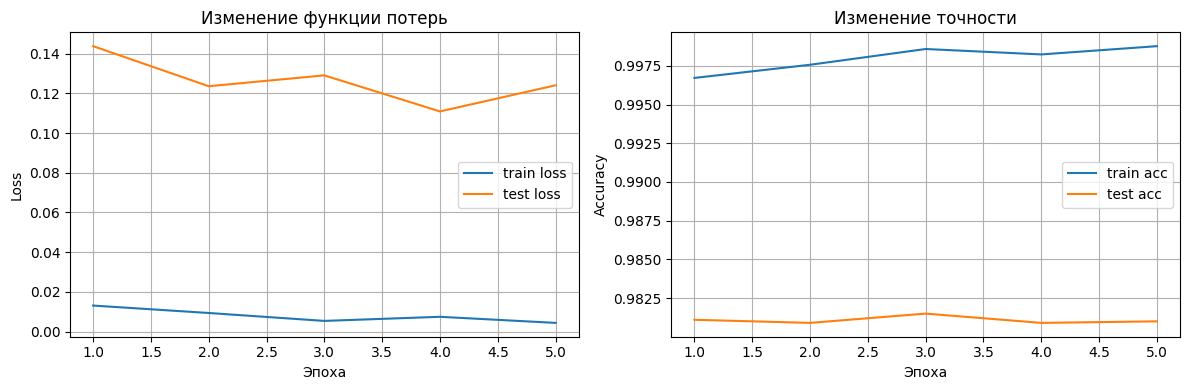

Финальная точность: train=0.9988, test=0.9810


In [43]:
epochs = np.arange(1, num_epochs + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], label="train loss")
plt.plot(epochs, history["test_loss"], label="test loss")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Изменение функции потерь")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_acc"], label="train acc")
plt.plot(epochs, history["test_acc"], label="test acc")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("Изменение точности")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Финальная точность: train={history['train_acc'][-1]:.4f}, test={history['test_acc'][-1]:.4f}")

### Ваш комментарий по кривым обучения

Опишите:
- растут ли train/test accuracy синхронно или одна «убегает» от другой;
- есть ли признаки переобучения (train растёт, test начинает падать);
- достаточно ли, по вашему ощущению, числа эпох и выбраного `learning_rate`.

Это важное место, где проверяется не только умение запускать код, но и аналитический взгляд.


In [45]:
training_comment = """train acc стабильно растет, test acc тоже растет, но не так стабильно.
Исходя из графика потерь становится заметно, что после монотонного снижения test loss начинает расти, что может быть признаком переообучения.
В это время train loss почти стабильно снижается.

На 3 эпохе вполне можно было бы заканочить обучение, поскольку точность и train и test была достаточно высокой, но потери не самыми низкими.
В целом и на 5 эпохе точность высокая"""
print(training_comment)

train acc стабильно растет, test acc тоже растет, но не так стабильно.
Исходя из графика потерь становится заметно, что после монотонного снижения test loss начинает расти, что может быть признаком переообучения.
В это время train loss почти стабильно снижается.

На 3 эпохе вполне можно было бы заканочить обучение, поскольку точность и train и test была достаточно высокой, но потери не самыми низкими.
В целом и на 5 эпохе точность высокая


## 8. Ошибки модели: что она путает

Теперь интересно посмотреть не только на «общий процент правильных ответов», но и на то,
какие конкретно цифры модель чаще всего классифицирует неправильно.

Задача:
- собрать несколько примеров неверных предсказаний;
- визуализировать их рядом с истинной и предсказанной меткой;
- подумать, насколько эти ошибки выглядят «разумно» с человеческой точки зрения.


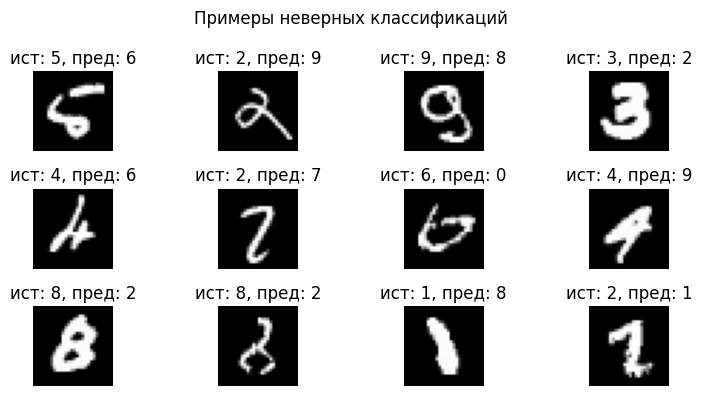

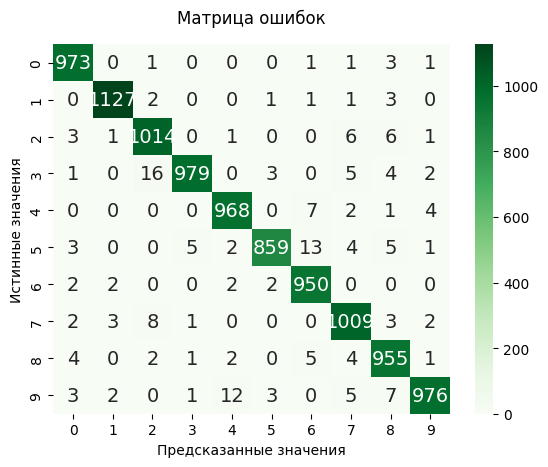

In [ ]:
model.eval()
wrong_images = []
wrong_true = []
wrong_pred = []

# тут собирается до первых 12 ошибок
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)

        mismatched = preds != labels
        if mismatched.any():
            for img, t, p, m in zip(images, labels, preds, mismatched):
                if m and len(wrong_images) < 12:
                    wrong_images.append(img.cpu())
                    wrong_true.append(t.cpu().item())
                    wrong_pred.append(p.cpu().item())
        if len(wrong_images) >= 12:
            break

plt.figure(figsize=(8, 4))
for i in range(len(wrong_images)):
    plt.subplot(3, 4, i + 1)
    plt.imshow(wrong_images[i].squeeze().numpy(), cmap="gray")
    plt.title(f"ист: {wrong_true[i]}, пред: {wrong_pred[i]}")
    plt.axis("off")
plt.suptitle("Примеры неверных классификаций")
plt.tight_layout()
plt.show()

# TODO: Постройте матрицу ошибок
y_true = []   
y_pred = [] 

# прошла по всем картинкам
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', annot_kws={'fontsize': 14})
plt.ylabel('Истинные значения')
plt.xlabel('Предсказанные значения')
plt.title('Матрица ошибок', pad=15)
plt.show()


### Краткий анализ ошибок (заполните сами)

Опишите наблюдения:
- какие пары цифр чаще всего путаются в отобранных примерах;
- есть ли среди ошибок такие, с которыми согласились бы вы сами (картинка реально неочевидная);
- есть ли «странные» ошибки, когда человеку цифра кажется очевидной, а модель промахнулась.


In [60]:
errors_comment = """Если исходить из матрицы ошибок, то самые частые несовпадения появляются в парах:
    3 и 2, 5 и 6, 9 и 4.
На примерах есть действительно неочевидные картинки, где вероятность спутать очень высока даже человеку.
    однако есть и такие, где, наоборот, всё очевидно, например 2 и 9.
"""
print(errors_comment)

Если исходить из матрицы ошибок, то самые частые несовпадения появляются в парах:
    3 и 2, 5 и 6, 9 и 4.
На примерах есть действительно неочевидные картинки, где вероятность спутать очень высока даже человеку.
    однако есть и такие, где, наоборот, всё очевидно, например 2 и 9.



## 9. Итоговые выводы по лабораторной работе

Эта часть — ключевая для проверки понимания.  
Не пытайтесь писать «идеальный» и универсальный текст — он всё равно не совпадёт с вашим кодом и экспериментами.

Ответьте в свободной форме (примерно 10–15 предложений):
1. Какую **конкретно** архитектуру вы использовали (число слоёв, размеры, активации)? Пробовали ли вы другие варианты и что изменилось?
2. Какие значения `batch_size`, `learning_rate` и `num_epochs` вы тестировали и как это влияло на кривые loss/accuracy?
3. Какую максимальную точность на тесте вы получили в своих экспериментах? Считаете ли вы её удовлетворительной для такой модели?
4. Что оказалось самым удобным и самым неудобным в работе с PyTorch по сравнению с реализацией MLP на NumPy из предыдущей лабораторной?

Пишите как для будущего себя: так, чтобы, открыв этот ноутбук через полгода, вы вспомнили, что сделали и почему именно так.


In [70]:
final_text = """Я использовала почти предложенную архитектуру, но добавила один скрытый слой для плавного перехода.
При предложенной архитектуре точность была чуть ниже. Также пробовала активацию Leaky ReLU, на ней точноость была примерно такой же, как на ReLU.
Остановилась на ReLU из-за ее простоты.

Рвазмеры batch_size пробовала различные(про них писала отдельно!). Для различных оптимизаторов выбирала разные настройки learning_rate и num_epochs:
    для AdamW и Adam я выбрала скорость ниже 1e-3, количество эпох меньше, а для SGD - наоборот, высокую скорость и большое количество эпох.
    Значения Adam были почти такими же как у AdamW, но AdamW показал более стабильный график, поэтому оставила его.

Самая большая точность ~98%. Я считаю ее удовлетворительной, но могла бы быть и выше, если бы добавлялись какие-либо дополнительные методы.
Для данной задачи 98% - хороший результат.

В PyTorch уже есть готовые функции активации Linear, ReLU. 
Удобно, что можно переносить тензоры на GPU для более быстрой работы, но нужно следить и на моем ноутбуке не работает)
"""
print(final_text)

Я использовала почти предложенную архитектуру, но добавила один скрытый слой для плавного перехода.
При предложенной архитектуре точность была чуть ниже. Также пробовала активацию Leaky ReLU, на ней точноость была примерно такой же, как на ReLU.
Остановилась на ReLU из-за ее простоты.

Рвазмеры batch_size пробовала различные(про них писала отдельно!). Для различных оптимизаторов выбирала разные настройки learning_rate и num_epochs:
    для AdamW и Adam я выбрала скорость ниже 1e-3, количество эпох меньше, а для SGD - наоборот, высокую скорость и большое количество эпох.
    Значения Adam были почти такими же как у AdamW, но AdamW показал более стабильный график, поэтому оставила его.

Самая большая точность ~98%. Я считаю ее удовлетворительной, но могла бы быть и выше, если бы добавлялись какие-либо дополнительные методы.
Для данной задачи 98% - хороший результат.

В PyTorch уже есть готовые функции активации Linear, ReLU. 
Удобно, что можно переносить тензоры на GPU для более быстрой 